# Behavioral Basics -- Biases That Break Judgment

Security decisions are made by humans, and humans make predictable errors. Anchoring warps estimates,
overconfidence inflates certainty, and framing flips preferences without changing
the underlying facts. None of these are random noise -- they are systematic,
directional, and measurable.

The field of behavioral decision science -- built on decades of work by Kahneman, Tversky, and others -- has identified dozens of cognitive biases. We focus here on the handful that have the largest demonstrated impact on risk estimation and resource allocation in organizational settings. Each bias is paired with at least one practical countermeasure that can be implemented without changing your toolchain or hiring a behavioral scientist.

This notebook walks through these biases with synthetic data, demonstrates each with interactive code, and introduces lightweight debiasing techniques that any analyst can adopt.

### Why this matters for security

Every time a CISO estimates breach likelihood, a SOC analyst triages an alert, or a board member evaluates a risk report, cognitive biases are shaping the outcome. These are not random mistakes -- they are systematic patterns that push estimates in consistent directions. Understanding them turns "people are bad at risk" from a vague complaint into a concrete list of failure modes you can test for and mitigate.

The security domain is particularly susceptible because it combines rare events, high stakes, ambiguous feedback, and time pressure -- exactly the conditions under which heuristics substitute for analysis. A SOC analyst processing 500 alerts per shift *must* use shortcuts; the question is whether those shortcuts are calibrated or arbitrary.

## Setup

We use `decision-security`'s Bayes module for updating beliefs and scoring
predictions, and `synth` for generating simulated judgment data.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

from decision_security.synth import make_rng, sample
from decision_security.bayes import beta_update, brier_score, calibration_curve

rng = make_rng(42)
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

PRIMARY = "#1A1A1A"
ACCENT = "#E74C3C"
DARK_BG = "#34495E"
LIGHT_GRAY = "#95A5A6"
MED_GRAY = "#7F8C8D"
VERY_LIGHT = "#BDC3C7"


## Anchoring

**Anchoring** occurs when an irrelevant number influences a subsequent estimate. In experiments, spinning a random wheel before asking people to estimate the number of African countries in the UN reliably shifts their answers toward the wheel's number. In security, the anchor is often the last incident's cost, a vendor's "average breach" statistic, or whatever number appeared on the previous slide.

The practical effect: if your threat-intelligence vendor opens a briefing with "$4.88M average breach cost," every estimate your team produces in that meeting will drift toward that figure -- regardless of whether it reflects your organization's size, industry, or control posture. Awareness helps, but the most reliable countermeasure is to elicit estimates *before* presenting reference data, then update deliberately.

We simulate two analyst groups -- one primed with a low anchor (2 incidents) and one with a high anchor (20 incidents) -- and compare the resulting estimates. The true mean is 8 incidents/month. Both groups should converge there, but anchoring pulls them apart.

> **Tip:** In risk workshops, collect initial estimates via anonymous written submission *before* any data is presented or discussed. This produces unanchored baselines that you can then refine with evidence. The difference between anchored and unanchored estimates is often striking -- and itself becomes a teaching moment about the power of the bias.

In [2]:
true_mean = 8
n_analysts = 200

# Group A: anchored at 2  -> estimates cluster low
group_a = sample("normal", n_analysts, rng=rng, loc=5.0, scale=2.5)

# Group B: anchored at 20 -> estimates cluster high
group_b = sample("normal", n_analysts, rng=rng, loc=14.0, scale=3.0)

print(f"Group A (anchor=2):  mean estimate = {group_a.mean():.1f}")
print(f"Group B (anchor=20): mean estimate = {group_b.mean():.1f}")
print(f"True monthly mean:   {true_mean}")

Group A (anchor=2):  mean estimate = 4.9
Group B (anchor=20): mean estimate = 14.1
True monthly mean:   8


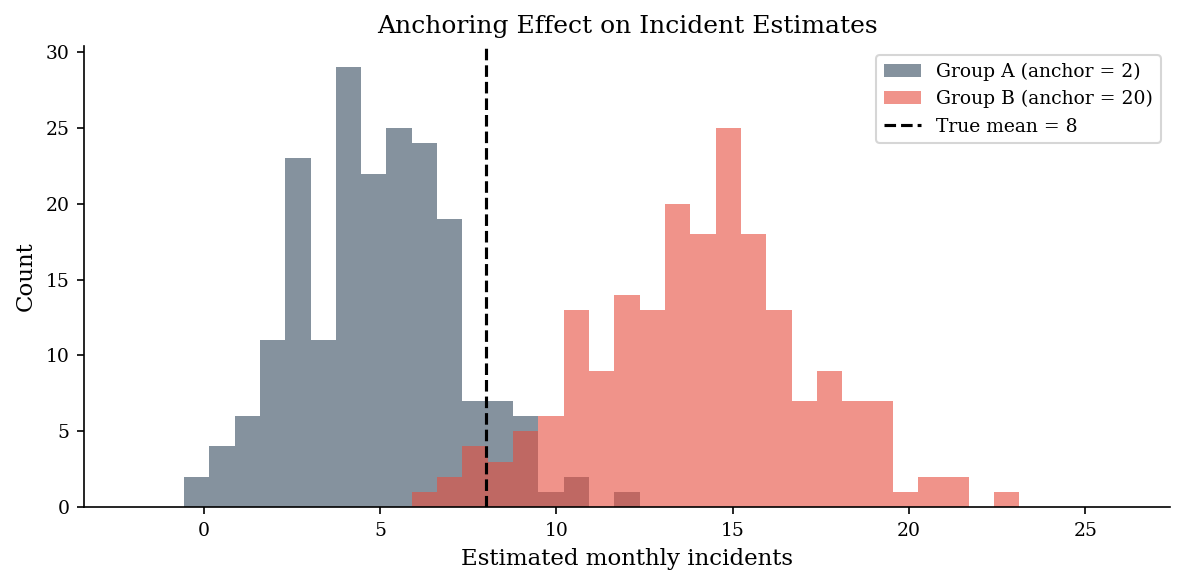

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
bins = np.linspace(-2, 26, 40)
ax.hist(group_a, bins=bins, alpha=0.6, label="Group A (anchor = 2)", color=DARK_BG)
ax.hist(group_b, bins=bins, alpha=0.6, label="Group B (anchor = 20)", color=ACCENT)
ax.axvline(true_mean, color="black", ls="--", lw=1.5, label=f"True mean = {true_mean}")
ax.set_xlabel("Estimated monthly incidents")
ax.set_ylabel("Count")
ax.set_title("Anchoring Effect on Incident Estimates")
ax.legend()
plt.tight_layout()
plt.show()

## Overconfidence and Calibration

Most people -- including domain experts -- produce confidence intervals that are far too narrow. When asked for a 90% confidence interval, well-calibrated estimators should contain the true answer 90% of the time. In practice, most people's "90% intervals" contain the truth only 50-60% of the time. This means we are routinely more surprised by outcomes than we should be.

**Calibration** is measurable. The **Brier score** grades probabilistic forecasts:

$$\text{BS} = \frac{1}{N}\sum_{i=1}^{N}(f_i - o_i)^2$$

where $f_i$ is the forecasted probability and $o_i$ is the outcome (0 or 1). Perfect calibration yields a Brier score of 0. A **reliability diagram** plots predicted probabilities against observed frequencies -- a well-calibrated forecaster traces the diagonal.

Why does calibration matter operationally? Because every risk-based prioritization depends on probability estimates. If your team consistently rates events at 20% when they occur 40% of the time, your entire risk register is systematically under-weighted, and resource allocation follows suit. Calibration training -- giving people feedback on their prediction accuracy -- is one of the few interventions with robust evidence of improving judgment.

We simulate 50 binary events, generate a calibrated forecaster and an overconfident one, then compare their Brier scores and reliability diagrams. Even small improvements in calibration translate to better resource allocation.

In [4]:
n_events = 50

# True base rates for each event (uniform draw)
true_probs = rng.uniform(0.1, 0.9, size=n_events)

# Outcomes drawn from those base rates
outcomes = rng.binomial(1, true_probs)

# Calibrated forecaster: slight noise around true probability
calibrated = np.clip(true_probs + rng.normal(0, 0.05, n_events), 0.01, 0.99)

# Overconfident forecaster: push probabilities toward extremes
overconfident = np.clip(0.5 + 1.6 * (true_probs - 0.5) + rng.normal(0, 0.05, n_events), 0.01, 0.99)

bs_cal = brier_score(calibrated, outcomes)
bs_over = brier_score(overconfident, outcomes)

print(f"Brier score (calibrated):     {bs_cal:.4f}")
print(f"Brier score (overconfident):  {bs_over:.4f}")
print(f"Lower is better. Overconfidence penalty: +{bs_over - bs_cal:.4f}")

Brier score (calibrated):     0.1558
Brier score (overconfident):  0.1395
Lower is better. Overconfidence penalty: +-0.0162


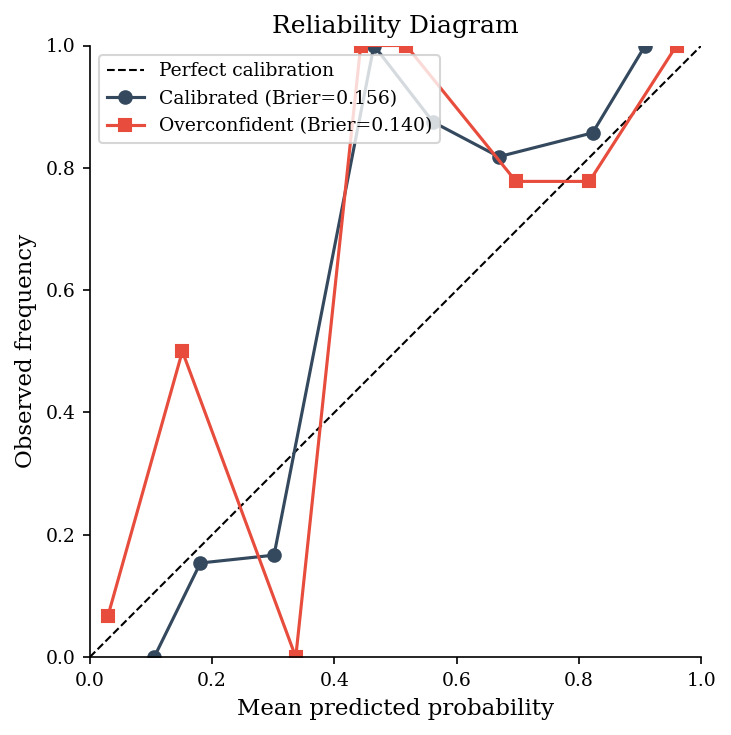

In [5]:
bins_k = 8
cen_cal, emp_cal = calibration_curve(calibrated, outcomes, bins=bins_k)
cen_over, emp_over = calibration_curve(overconfident, outcomes, bins=bins_k)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Perfect calibration")
ax.plot(cen_cal, emp_cal, "o-", color=DARK_BG, label=f"Calibrated (Brier={bs_cal:.3f})")
ax.plot(cen_over, emp_over, "s-", color=ACCENT, label=f"Overconfident (Brier={bs_over:.3f})")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed frequency")
ax.set_title("Reliability Diagram")
ax.legend(loc="upper left", fontsize=9)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## Framing and Loss Aversion

Prospect theory shows that people weight losses roughly **twice as heavily** as equivalent gains. This is **loss aversion**, and it interacts with **framing** to produce inconsistent decisions. Telling a board "this control saves \$3M in expected losses" produces a different reaction than "without this control, we face \$3M in expected losses" -- even though the information is identical.

For security teams, this cuts both ways. Loss framing can help secure funding for genuinely important controls, but it can also create panic-driven overspending. The disciplined approach is to present both frames side by side and let the numbers -- not the emotional frame -- drive the decision.

A related trap is **reference-point dependence**. Whether a 15% reduction in incident frequency feels like progress or failure depends entirely on what stakeholders expected. If the target was 20%, it feels like failure; if no target was set, it feels like success. Setting explicit, quantified baselines before measuring outcomes prevents this kind of post-hoc reframing.

"We blocked 97% of phishing emails" and "3% of phishing emails reached
employees" describe the same metric. But the first sounds like success
and the second sounds like failure.

If your organization receives 10,000 phishing emails per month,
that 3% means 300 malicious emails landing in inboxes. We simulate
the number of successful phishes (clicks) from those 300 delivered
emails to show the operational reality behind the framing -- and how identical metrics produce divergent perceived urgency depending on whether they are framed as gains or losses.

In [6]:
phishing_volume = 10_000       # total phishing emails/month
filter_rate = 0.97             # "we block 97%"
delivered = int(phishing_volume * (1 - filter_rate))  # 300
click_rate = 0.12              # industry-typical click-through on delivered phish

n_months = 1000
clicks_per_month = sample("binomial", n_months, rng=rng, n=delivered, p=click_rate)

print(f"Framing A: 'We blocked {filter_rate:.0%} of phishing.'")
print(f"Framing B: '{delivered} phishing emails reached employees each month.'")
print(f"")
print(f"Simulated clicks/month over {n_months} months:")
print(f"  Mean:   {clicks_per_month.mean():.1f}")
print(f"  Median: {np.median(clicks_per_month):.0f}")
print(f"  P95:    {np.percentile(clicks_per_month, 95):.0f}")
print(f"  Max:    {clicks_per_month.max()}")

Framing A: 'We blocked 97% of phishing.'
Framing B: '300 phishing emails reached employees each month.'

Simulated clicks/month over 1000 months:
  Mean:   36.0
  Median: 36
  P95:    45
  Max:    57


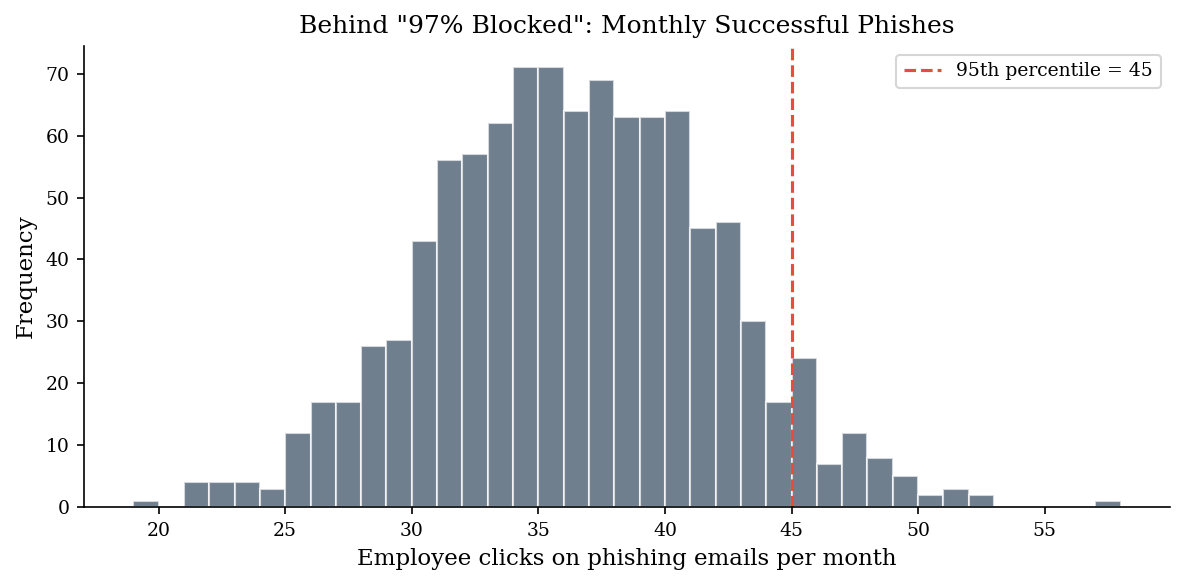

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(clicks_per_month, bins=range(int(clicks_per_month.min()), int(clicks_per_month.max()) + 2),
        color=DARK_BG, alpha=0.7, edgecolor="white")
ax.axvline(np.percentile(clicks_per_month, 95), color=ACCENT, ls="--",
           label=f"95th percentile = {np.percentile(clicks_per_month, 95):.0f}")
ax.set_xlabel("Employee clicks on phishing emails per month")
ax.set_ylabel("Frequency")
ax.set_title('Behind "97% Blocked": Monthly Successful Phishes')
ax.legend()
plt.tight_layout()
plt.show()

## Bayesian Update -- Structured Reasoning as Bias Antidote

Bayesian updating provides a mechanical antidote to several biases at once. The process is simple: start with a **prior** belief (your estimate before new evidence), observe **evidence** (a pentest result, an incident report, a new threat-intel feed), compute the **likelihood** of that evidence under different hypotheses, and derive a **posterior** belief.

Writing this down -- literally filling in the prior, the likelihood, and computing the posterior -- forces you to separate what you knew before from what the evidence actually tells you. It prevents anchoring on the prior, prevents overweighting dramatic evidence, and creates an auditable trail of reasoning. You do not need to be a statistician; even rough estimates plugged into Bayes' rule produce better-calibrated updates than unaided intuition.

### Patch Compliance Example

Before collecting data, our prior belief about the patch compliance rate
is $\text{Beta}(7, 3)$ -- we think compliance is probably around 70% but we are
not very certain.

We then observe 85 patched systems out of 110 checked (25 unpatched).
The conjugate update shifts our belief toward the data. Rather than replacing the prior with the sample proportion (recency bias) or ignoring the data (anchoring on the prior), the Bayesian update combines both -- weighting each by its precision. The posterior will land between the prior mean and the data proportion, closer to whichever estimate is backed by more data.

In [8]:
a_prior, b_prior = 7, 3
successes, failures = 85, 25

a_post, b_post = beta_update(a_prior, b_prior, successes, failures)

prior_mean = a_prior / (a_prior + b_prior)
post_mean = a_post / (a_post + b_post)

print(f"Prior:     Beta({a_prior}, {b_prior})  ->  mean = {prior_mean:.3f}")
print(f"Data:      {successes}/{successes + failures} patched")
print(f"Posterior: Beta({a_post:.0f}, {b_post:.0f})  ->  mean = {post_mean:.3f}")

Prior:     Beta(7, 3)  ->  mean = 0.700
Data:      85/110 patched
Posterior: Beta(92, 28)  ->  mean = 0.767


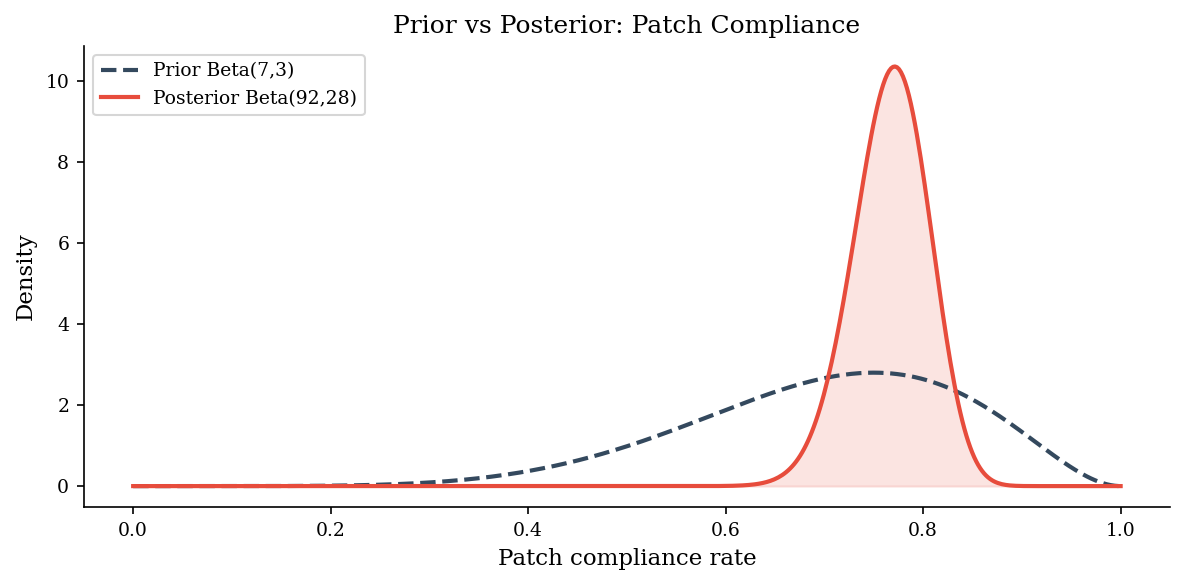

In [9]:
x = np.linspace(0, 1, 500)
prior_pdf = stats.beta.pdf(x, a_prior, b_prior)
post_pdf = stats.beta.pdf(x, a_post, b_post)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, prior_pdf, "--", color=DARK_BG, lw=2, label=f"Prior Beta({a_prior},{b_prior})")
ax.plot(x, post_pdf, "-", color=ACCENT, lw=2, label=f"Posterior Beta({a_post:.0f},{b_post:.0f})")
ax.fill_between(x, post_pdf, alpha=0.15, color=ACCENT)
ax.set_xlabel("Patch compliance rate")
ax.set_ylabel("Density")
ax.set_title("Prior vs Posterior: Patch Compliance")
ax.legend()
plt.tight_layout()
plt.show()

## Premortem: Debiasing Through Prospective Hindsight

A **premortem** inverts the usual project review. Instead of asking "what could go wrong?" (which triggers optimism bias), you state: "It is six months from now, and this initiative has failed. Why?" Research by Gary Klein shows that this prospective-hindsight framing increases the ability to identify failure modes by roughly **30%**.

For security programs, premortems are especially valuable before major control deployments, architecture changes, or policy rollouts. The technique is fast (15-30 minutes in a group setting) and requires no special tools -- just the discipline to assume failure and work backward.

The premortem is also a useful political tool. It gives team members permission to voice concerns that would otherwise be seen as "not being a team player." Framing criticism as a hypothetical failure scenario removes the interpersonal risk of disagreeing with a senior leader's preferred approach.

### Scenario: SIEM Deployment

**Prompt:** It is six months from now. The new SIEM deployment has failed.
The SOC is back to manual log review. What went wrong?

Typical premortem outputs:

1. **Data quality** -- Log sources were inconsistent; normalization rules
   took 4x longer than planned.
2. **Alert fatigue** -- Default correlation rules generated 2,000+ alerts/day;
   analysts ignored the platform within weeks.
3. **Staffing** -- Two senior engineers left mid-project; tribal knowledge
   of the legacy SIEM was lost.
4. **Vendor lock-in** -- The licensing model changed at renewal; budget
   was not approved for year two.
5. **Scope creep** -- Compliance added 30 new log sources after sign-off;
   no additional resources were allocated.

Each of these is a testable risk that can be monitored and mitigated
*before* the project starts -- but they rarely surface in a standard
risk register because optimism bias suppresses them.

## The Allais Paradox: When Rational Preferences Break

The Allais paradox (1953), extensively discussed by Raiffa (1968), demonstrates that most people's risk preferences violate the axioms of expected utility -- and that *showing them the violation* often changes their answer. This is the difference between **descriptive** and **prescriptive** decision theory: descriptive theory documents how people actually choose (often inconsistently); prescriptive theory provides a framework for choosing *consistently*. People don't naturally reason consistently about risk, but when the inconsistency is made explicit, they can correct it.

**Recast as a security investment decision:**

**Problem 1:** Choose between:
- **A1:** Guaranteed \$1M compliance outcome (certainty)
- **A2:** 10% chance of \$5M transformation, 89% chance of \$1M compliance, 1% chance of \$0

**Problem 2:** Choose between:
- **A3:** 10% chance of \$5M transformation, 90% chance of \$0
- **A4:** 11% chance of \$1M compliance, 89% chance of \$0

Most people choose A1 over A2 (preferring certainty) **and** A3 over A4
(preferring the bigger upside). But this pair of choices violates expected
utility theory -- you cannot consistently hold both preferences under any
utility function.

Raiffa's insight: once the inconsistency is pointed out, most people revise their preferences. The prescriptive framework doesn't tell people what to want -- it helps them want *consistently*.

The practical takeaway is not that people should be forced to follow utility theory robotically. It is that when a decision-maker registers inconsistent preferences across two similar choices, the inconsistency should be surfaced and resolved before investment decisions are made -- not discovered after the budget is committed.

In [10]:
# Allais Paradox: checking for EU consistency
# If u(1M) = u1, u(5M) = u5, u(0) = 0

# Problem 1: A1 preferred to A2
# u1 > 0.10*u5 + 0.89*u1 + 0.01*0
# u1 - 0.89*u1 > 0.10*u5
# 0.11*u1 > 0.10*u5

# Problem 2: A3 preferred to A4
# 0.10*u5 > 0.11*u1
# This CONTRADICTS Problem 1!

print("=== Allais Paradox: Consistency Check ===")
print()
print("If you prefer A1 over A2:")
print("  → 0.11 * u($1M) > 0.10 * u($5M)")
print()
print("If you prefer A3 over A4:")
print("  → 0.10 * u($5M) > 0.11 * u($1M)")
print()
print("These two preferences CONTRADICT each other.")
print("No utility function can satisfy both simultaneously.")
print()
print("In security: if you prefer the guaranteed compliance outcome")
print("in Problem 1 but chase the transformation upside in Problem 2,")
print("your risk appetite is internally inconsistent — and a vendor")
print("can exploit that inconsistency.")

=== Allais Paradox: Consistency Check ===

If you prefer A1 over A2:
  → 0.11 * u($1M) > 0.10 * u($5M)

If you prefer A3 over A4:
  → 0.10 * u($5M) > 0.11 * u($1M)

These two preferences CONTRADICT each other.
No utility function can satisfy both simultaneously.

In security: if you prefer the guaranteed compliance outcome
in Problem 1 but chase the transformation upside in Problem 2,
your risk appetite is internally inconsistent — and a vendor
can exploit that inconsistency.


## Intransitive Preferences: The Money Pump

Raiffa (1968) illustrated intransitivity with a property-selection example where each pairwise comparison is won by a different alternative: A beats B, B beats C, but C beats A. This cycle arises naturally when different criteria dominate different comparisons -- the decision-maker implicitly switches evaluation criteria between pairs.

In security, this manifests when control comparisons use shifting criteria. EDR beats WAF on threat coverage, WAF beats SIEM on cost, SIEM beats EDR on compliance evidence. Each pairwise judgment feels reasonable, but the cycle means the ranking is exploitable -- in Raiffa's terms, the decision-maker is a **"money pump"** from whom value can be extracted through sequential trades around the cycle. A vendor who knows your implicit criteria-switching can always offer you a "better" trade, extracting value at each step of the cycle indefinitely.

**Security version:** A CISO ranks three controls:
- **EDR > WAF** because EDR has better threat coverage and lower FP rate
- **WAF > SIEM** because WAF is cheaper and faster to deploy
- **SIEM > EDR** because SIEM provides compliance evidence and broader visibility

The resolution is not to suppress multi-criteria evaluation but to make it explicit and consistent. MCDA (Chapter 0.6) forces the decision-maker to fix criteria weights *before* comparing alternatives, which eliminates the implicit weight-switching that produces cycles. The discomfort of fixing weights is the point -- it surfaces the trade-offs that intransitive preferences keep hidden.

In [11]:
# Intransitive preferences demonstration
# Three controls scored on three criteria, each comparison uses different weights

controls = ["EDR", "WAF", "SIEM"]
criteria = ["Threat Coverage", "Cost", "Compliance"]

# Scores (0-10)
scores = {
    "EDR":  [9, 5, 4],   # great coverage, moderate cost, weak compliance
    "WAF":  [6, 8, 5],   # moderate coverage, cheap, moderate compliance
    "SIEM": [5, 3, 9],   # weak coverage, expensive, great compliance
}

# Pairwise comparisons with different implicit weight emphasis
comparisons = [
    ("EDR", "WAF",  [0.5, 0.3, 0.2]),  # threat-focused → EDR wins
    ("WAF", "SIEM", [0.2, 0.5, 0.3]),  # cost-focused → WAF wins
    ("SIEM", "EDR", [0.2, 0.3, 0.5]),  # compliance-focused → SIEM wins
]

print("=== Intransitive Rankings (shifting criteria weights) ===\n")
for a, b, weights in comparisons:
    score_a = sum(s * w for s, w in zip(scores[a], weights))
    score_b = sum(s * w for s, w in zip(scores[b], weights))
    winner = a if score_a > score_b else b
    print(f"  {a} vs {b} (weights: {dict(zip(criteria, weights))})")
    print(f"    {a}: {score_a:.1f}  vs  {b}: {score_b:.1f}  → {winner} wins")
    print()

print("Cycle: EDR > WAF > SIEM > EDR")
print("The CISO is a 'money pump' — the ranking is circular because")
print("different criteria dominate each pairwise comparison.")
print("\nFix: use consistent weights across ALL comparisons (→ MCDA).")

=== Intransitive Rankings (shifting criteria weights) ===

  EDR vs WAF (weights: {'Threat Coverage': 0.5, 'Cost': 0.3, 'Compliance': 0.2})
    EDR: 6.8  vs  WAF: 6.4  → EDR wins

  WAF vs SIEM (weights: {'Threat Coverage': 0.2, 'Cost': 0.5, 'Compliance': 0.3})
    WAF: 6.7  vs  SIEM: 5.2  → WAF wins

  SIEM vs EDR (weights: {'Threat Coverage': 0.2, 'Cost': 0.3, 'Compliance': 0.5})
    SIEM: 6.4  vs  EDR: 5.3  → SIEM wins

Cycle: EDR > WAF > SIEM > EDR
The CISO is a 'money pump' — the ranking is circular because
different criteria dominate each pairwise comparison.

Fix: use consistent weights across ALL comparisons (→ MCDA).


## Practical Guardrails

You cannot eliminate bias, but you can build processes that reduce its impact. Six rules that fit on an index card:

1. **Prior, evidence, posterior.** Write down your belief *before* you look
   at the data. Update explicitly. If you skip this step, anchoring and
   confirmation bias fill the gap.

2. **Intervals, not points.** Every estimate should come with a confidence interval. "We estimate 5-15% annual probability, 80% confidence" is more honest and more useful than "about 10%." This forces you to confront your own uncertainty and makes overconfidence visible.

3. **Consider the opposite.** Before finalizing any risk assessment, explicitly ask: "What evidence would make us believe the opposite conclusion?" If you cannot articulate any, the assessment is likely anchored, not reasoned.

4. **Separate elicitation from discussion.** Collect estimates independently before group discussion to prevent anchoring and groupthink. Aggregate afterward.

5. **Premortem before big bets.** Spend 15 minutes assuming failure and listing reasons before committing to a major control investment or architecture change. Cheap insurance against optimism bias.

6. **Brier-score your team.** Even tracking 20-30 binary forecasts per quarter gives you enough data to identify systematic miscalibration and coach individuals toward better estimation. Keep a log of probabilistic forecasts and check them against outcomes quarterly. You cannot improve calibration without a feedback loop.

> **Note:** These guardrails are not bureaucratic overhead -- they are the minimum viable process for treating risk estimates as testable predictions rather than rhetorical devices. Organizations that track and score their forecasts consistently outperform those that do not.

## What Good Looks Like

A mature security organization does not eliminate bias -- that is impossible. Instead, it builds processes that contain bias and make it detectable:

- Risk estimates carry explicit confidence intervals.
- Forecasts are logged and scored.
- Major decisions include a premortem.
- Briefings present both gain and loss frames.
- When new evidence arrives, the update follows a structured Bayesian template rather than "let me revise my gut feeling."

None of this requires perfection. Even partial adoption -- say, tracking 30 forecasts per quarter and reviewing calibration -- produces measurable improvement within two quarters. The key is consistency: a lightweight process followed every time beats an elaborate process used sporadically.

> **Tip:** Use the Brier scoring and reliability diagram code above as a starter template for a prediction log with automated scoring. Track your team's forecasts for one quarter and review the calibration curve -- the results are usually illuminating.